# PPSeq synthetic data demo with dynamic background rate

This notebook describes the newest changes to the PPSeq model for treating dynamic background rates.

The fundamental two changes are:

* Poisson GLM background model
* L1 regularization on templates

## Setup


In [8]:
try:
    import ppseq
except Exception:
    %pip install -q git+https://github.com/lindermanlab/ppseq-pytorch.git@main
    import ppseq

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from ppseq.plotting import plot_model, color_plot, plot_sorted_neurons
from ppseq.model import PPSeq, GLMPPSeq
from generate_data import generate_data_glm

In [10]:
# Progress bar utility: try fastprogress, then tqdm, else no-op
try:
    from fastprogress.fastprogress import progress_bar  # type: ignore
except Exception:
    try:
        from tqdm.auto import tqdm as progress_bar  # type: ignore
    except Exception:
        def progress_bar(x):
            return x

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if not torch.cuda.is_available():
    print('Could not find a GPU. Defaulting to CPU instead.')

Could not find a GPU. Defaulting to CPU instead.


## Generate synthetic data

First, we will generate synthetic data with a dynamics background rate. This will look like a spike train with region of both sparse and dense firing activity, meaning that a constant background rate model would by definition be insufficient in distinguishing the two regimes.

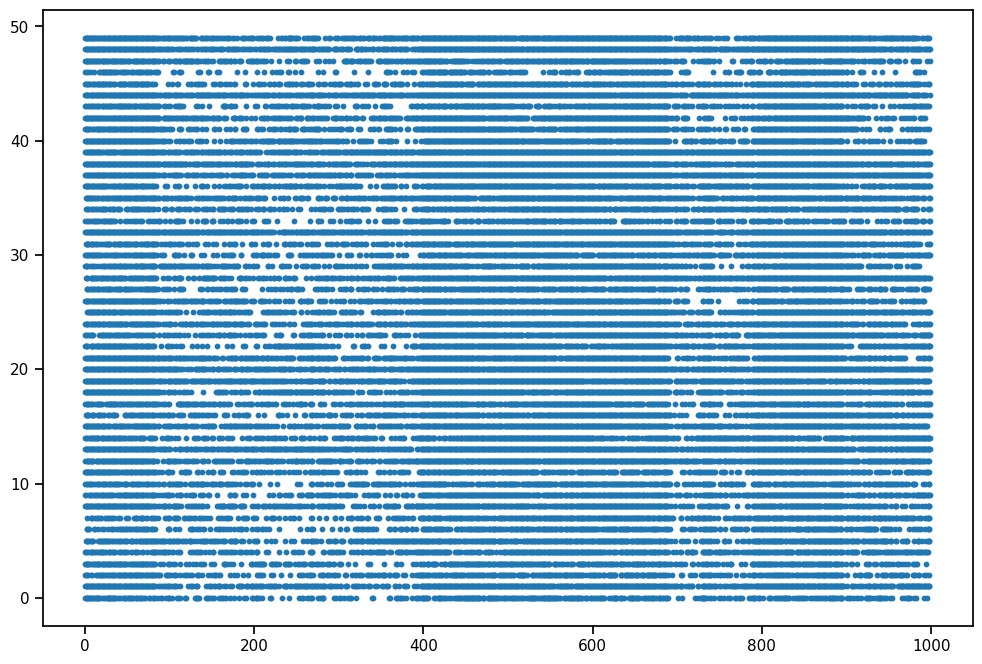

In [12]:
# Use GLM-based generator with dynamic background
N, T, K, D, P = 50, 1000, 2, 10, 4
seed = 1  # set to None for different random draws each run
num_segments = 8
# Dense segments get positive offsets in log-rate; sparse segments get negative.
# Tune magnitude ranges to control contrast between dense and sparse periods.
dense_strength_range = (0.4, 1.0)
sparse_strength_range = (0.2, 0.8)
X, lambdas, alpha, beta, X_cov, true_a, true_w, lambda_bg = generate_data_glm(
    N=N, T=T, K=K, D=D, P=P, seed=seed,
    num_segments=num_segments,
    dense_strength_range=dense_strength_range,
    sparse_strength_range=sparse_strength_range,
)

# Move to device
data = X.to(device)
num_neurons, num_timesteps = data.shape

plot_sorted_neurons(data)

## Failure mode - PPSeq with constant background rate

Applying the standard PPSeq model demonstrates the failure mode of constant the constant background rate model. While the model is able to sufficiently filter the background rate in the sparse region, it is unable to discern background firing from signal in the dense region. As a result, the learned templates are active throughout the densely active region, which provides little to no information as to the fitness of the learned templates.

Could not find a GPU. Defaulting to CPU instead.


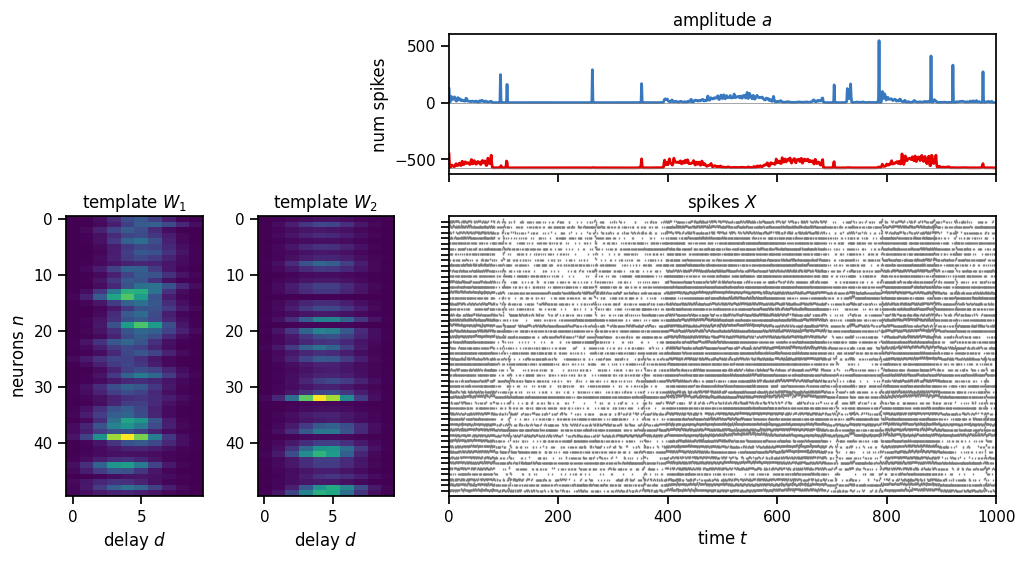

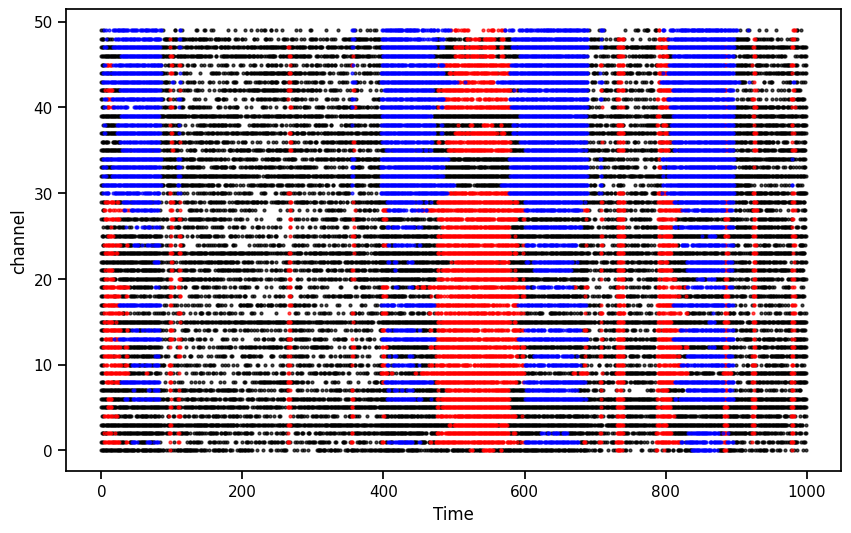

In [6]:
torch.manual_seed(0)
model = PPSeq(num_templates=K,
              num_neurons=num_neurons,
              template_duration=D,
              alpha_a0=1.5,
              beta_a0=0.2,
              alpha_b0=1,
              beta_b0=0.1,
              alpha_t0=1.2,
              beta_t0=0.1,
              )

lps, amplitudes = model.fit(data, num_iter=100)

plot_model(model.templates.cpu(),
           amplitudes.cpu(),
           data.cpu(),
           spc=.33)

color_plot(data.cpu(),
           model,
           amplitudes.cpu(),
           )

# GLM PPSeq

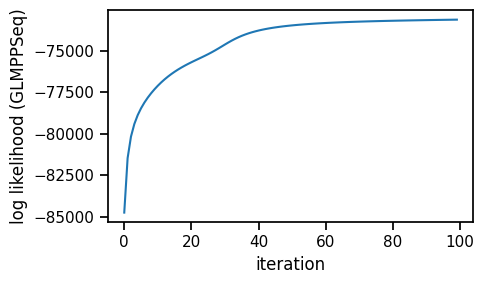

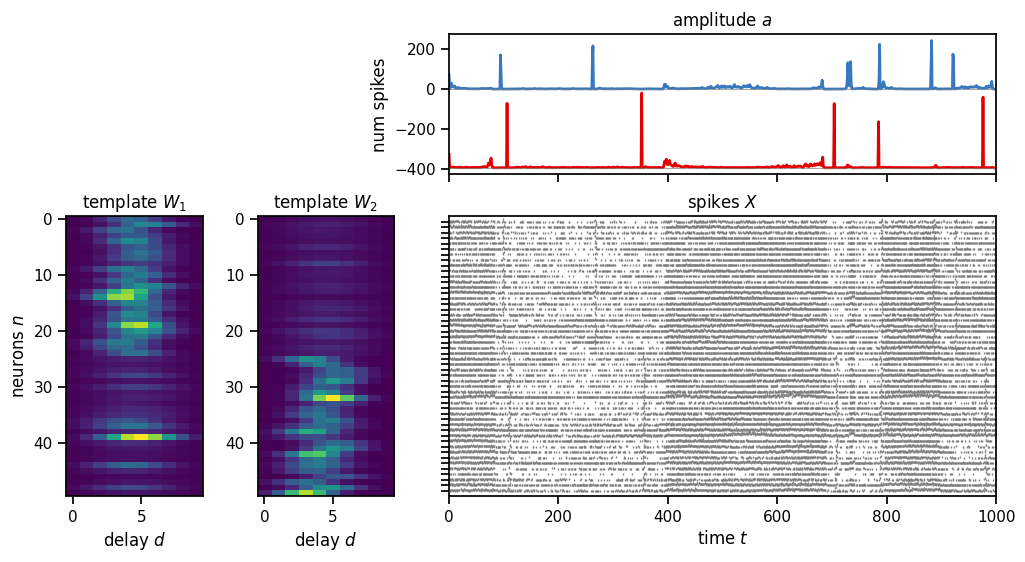

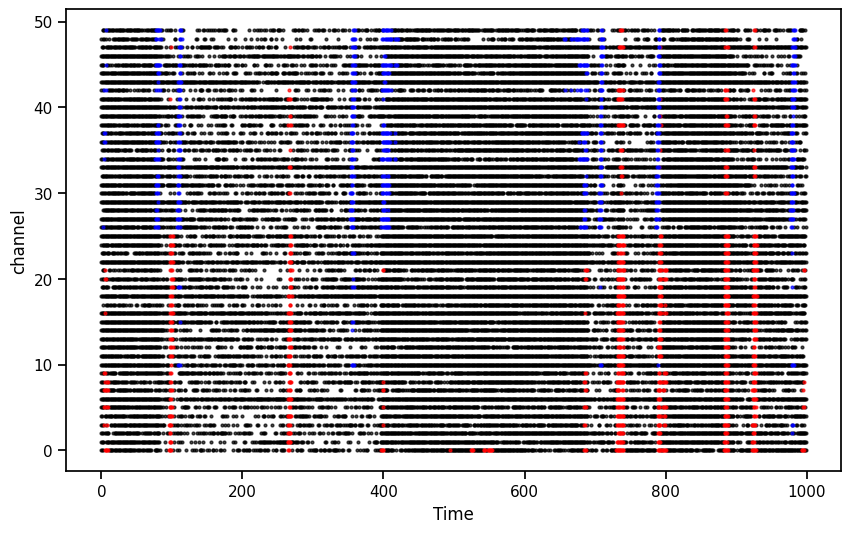

In [ ]:
# Use GLMPPSeq from ppseq.model as a separate run
torch.manual_seed(0)
glmppseq_model = GLMPPSeq(num_templates=K,
                         num_neurons=num_neurons,
                         template_duration=D,
                         alpha_a0=1.5,
                         beta_a0=0.2,
                         alpha_b0=1,
                         beta_b0=0.1,
                         alpha_t0=1.2,
                         beta_t0=0.1,
                         device=device,
                         use_bias=True,
                         empirical_glm=True,
                         n_covariates=5,
                         )

lps_glmpp, amplitudes_glmpp = glmppseq_model.fit(
    data,
    num_iter=100,
    initialization='random',
    fit_templates=True,
    fit_base_rates=True,
)

plt.figure(figsize=(5,3))
plt.plot(lps_glmpp.detach().cpu())
plt.xlabel('iteration')
plt.ylabel('log likelihood (GLMPPSeq)')
plt.tight_layout()
plt.show()

plot_model(glmppseq_model.templates.detach().cpu(),
           amplitudes_glmpp.detach().cpu(),
           data.detach().cpu(),
           spc=.33)

color_plot(data.detach().cpu(), glmppseq_model, amplitudes_glmpp.detach().cpu())

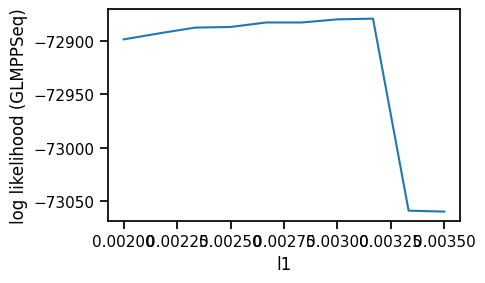

Best l1: 0.0031666666666666666


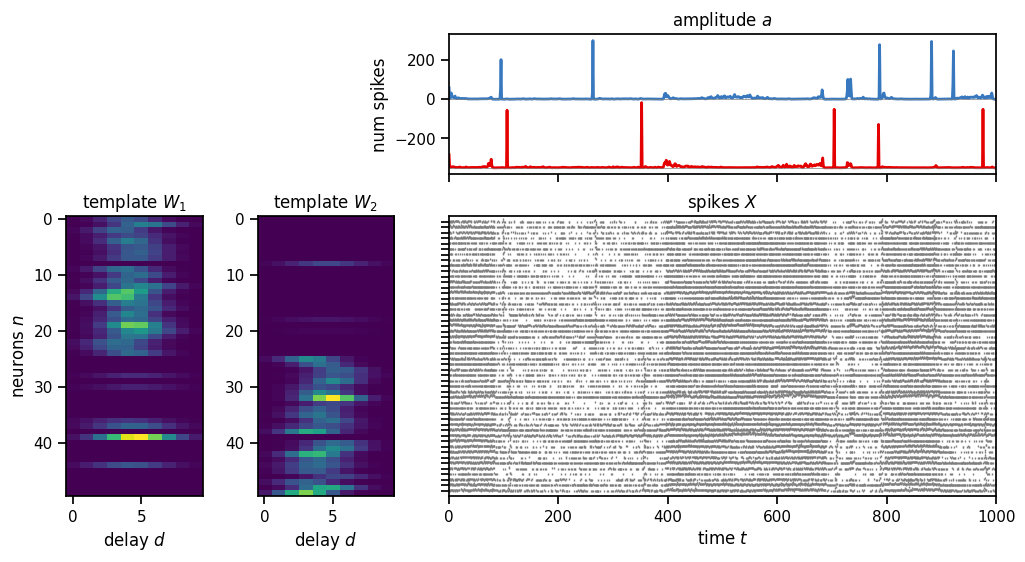

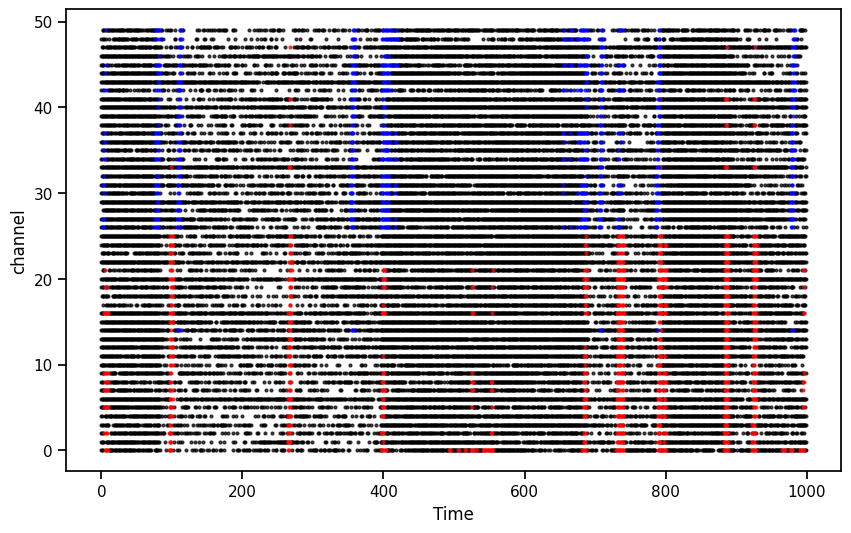

In [24]:
# l1s = [0.0, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3]
l1s = np.linspace(2e-3, 3.5e-3, 10)
final_lps = []
models = []
amplitudes = []

for l1 in l1s:  
    # Use GLMPPSeq from ppseq.model as a separate run
    torch.manual_seed(0)
    glmppseq_model = GLMPPSeq(num_templates=K,
                            num_neurons=num_neurons,
                            template_duration=D,
                            alpha_a0=1.5,
                            beta_a0=0.2,
                            alpha_b0=1,
                            beta_b0=0.1,
                            alpha_t0=1.2,
                            beta_t0=0.1,
                            device=device,
                            use_bias=True,
                            empirical_glm=True,
                            n_covariates=5,
                            l1=l1)

    lps_glmpp, amplitudes_glmpp = glmppseq_model.fit(
        data,
        num_iter=100,
        initialization='random',
        fit_templates=True,
        fit_base_rates=True,
    )
    final_lps.append(lps_glmpp[-1])
    models.append(glmppseq_model)
    amplitudes.append(amplitudes_glmpp)

# plot final log likelihoods
plt.figure(figsize=(5,3))
plt.plot(l1s, final_lps)
plt.xlabel('l1')
plt.ylabel('log likelihood (GLMPPSeq)')
plt.tight_layout()
plt.show()

# plot the best model
best_l1 = l1s[np.argmax(final_lps)]
best_model = models[np.argmax(final_lps)]
best_amplitudes = amplitudes[np.argmax(final_lps)]

print(f"Best l1: {best_l1}")

plot_model(best_model.templates.detach().cpu(),
           best_amplitudes.detach().cpu(),
           data.detach().cpu(),
           spc=.33)
color_plot(data.detach().cpu(), best_model, amplitudes[np.argmax(final_lps)].detach().cpu())

# delete the lists
del models, amplitudes, final_lps

# Multi-session data

Now we'll test both models on the multi-session data with ground truth sequences.

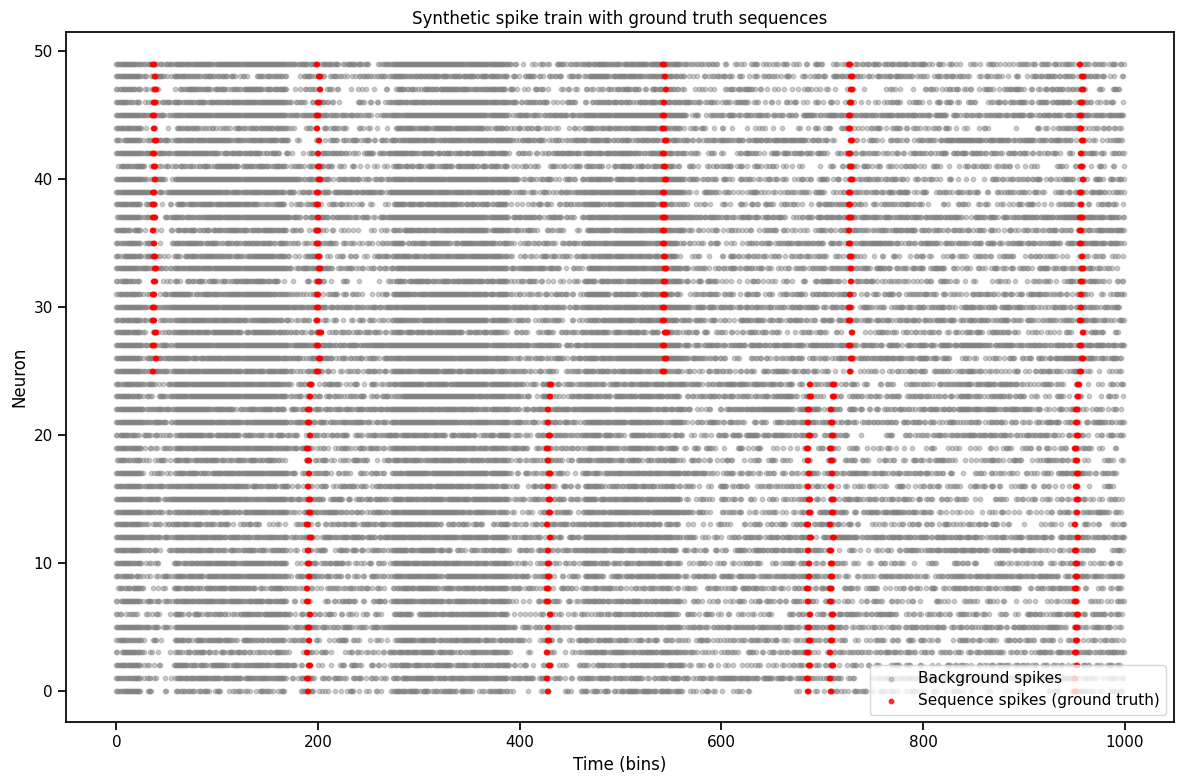

Total spikes: 27852
Sequence spikes: 678 (2.4%)
Background spikes: 27174


In [25]:
# Generate data with ground truth sequences using generate_data_glm_full
from generate_data import generate_data_glm_full
import torch.nn.functional as F

seed = 2

# Generate single session
(X_sessions, lambdas_sessions, alpha, beta, X_cov_sessions,
 true_a_sessions, true_w, lambda_bg_sessions, correct_sequences) = generate_data_glm_full(
    N=N, T=T, K=K, D=D, P=P, 
    num_sessions=1,
    seed=seed,
    num_segments=num_segments,
    dense_strength_range=dense_strength_range,
    sparse_strength_range=sparse_strength_range,
)

# Extract single session data
X_full = X_sessions[0]
X_seq = correct_sequences[0]

# Create binary mask for sequence spikes (any spike with non-zero sequence rate)
# The sequence component comes from convolving true_a with true_w
conv_term = F.conv1d(
    true_a_sessions[0],
    torch.flip(true_w.permute(1, 0, 2), [2]),
    padding=D - 1
)[:, : -D + 1]  # (N, T)

# Mark timepoints where sequence activity is present (above threshold)
seq_mask = conv_term > 0.1  # threshold to identify sequence activity regions

# Plot raster with ground truth sequences highlighted
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Get spike coordinates for all spikes
spike_coords = torch.nonzero(X_full.T)  # shape (num_spikes, 2) with columns [time, neuron]
spike_times = spike_coords[:, 0].cpu().numpy()
spike_neurons = spike_coords[:, 1].cpu().numpy()

# Identify which spikes are from sequences vs background
# A spike at (n, t) is a sequence spike if seq_mask[n, t] is True
is_sequence_spike = seq_mask.T[spike_coords[:, 0], spike_coords[:, 1]].cpu().numpy()

# Plot background spikes in gray
bg_mask = ~is_sequence_spike
ax.scatter(spike_times[bg_mask], spike_neurons[bg_mask], 
           c='gray', s=10, alpha=0.4, label='Background spikes')

# Overlay sequence spikes in red
ax.scatter(spike_times[is_sequence_spike], spike_neurons[is_sequence_spike], 
           c='red', s=10, alpha=0.8, label='Sequence spikes (ground truth)')

ax.set_xlabel('Time (bins)')
ax.set_ylabel('Neuron')
ax.set_title('Synthetic spike train with ground truth sequences')
ax.legend()
plt.tight_layout()
plt.show()

num_seq_spikes = is_sequence_spike.sum()
num_total_spikes = len(spike_times)
print(f"Total spikes: {num_total_spikes}")
print(f"Sequence spikes: {num_seq_spikes} ({100*num_seq_spikes/num_total_spikes:.1f}%)")
print(f"Background spikes: {num_total_spikes - num_seq_spikes}")

Could not find a GPU. Defaulting to CPU instead.


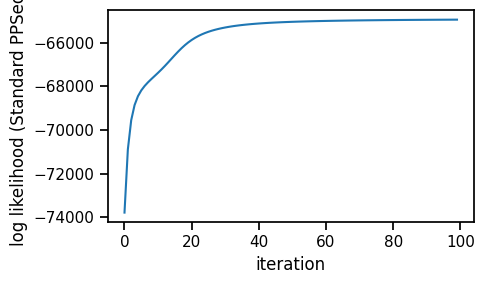

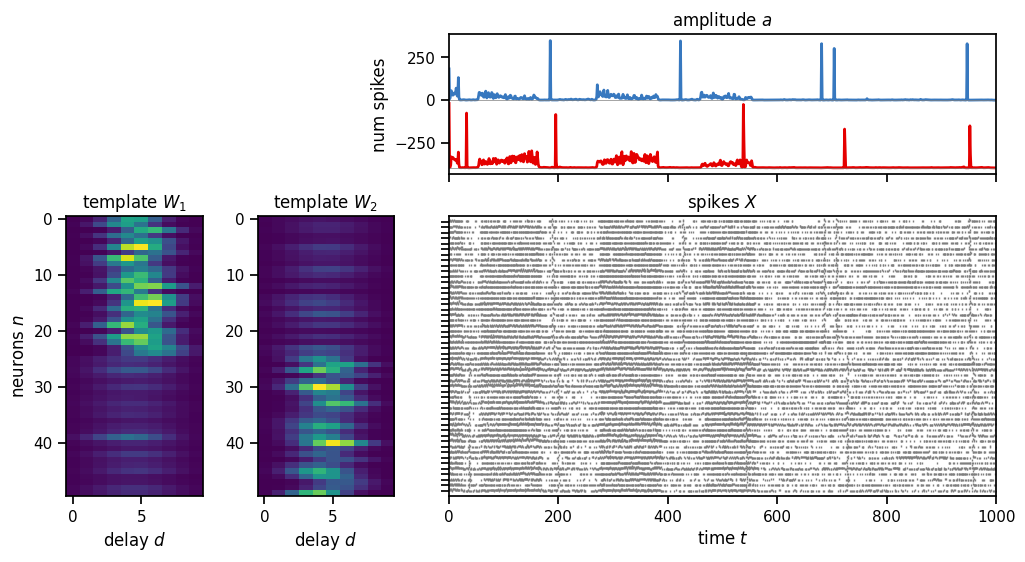

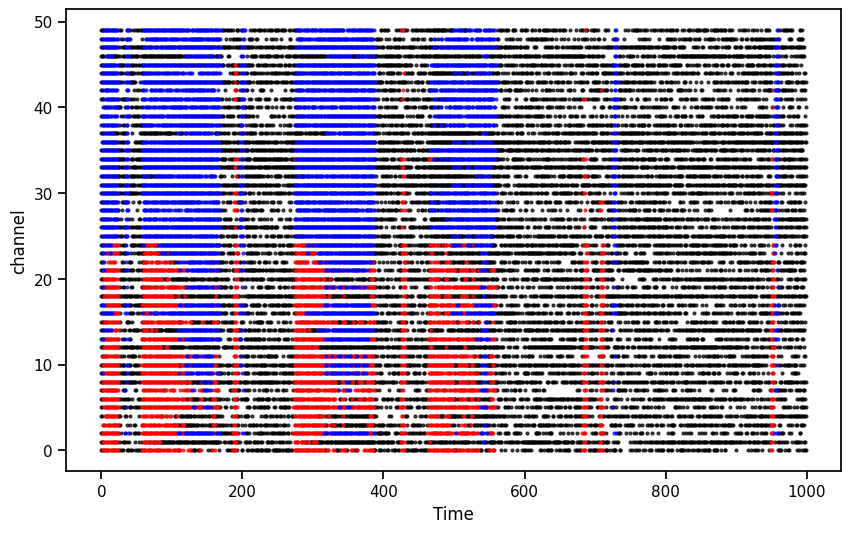

In [22]:
# Apply standard PPSeq model to the multi-session data
torch.manual_seed(0)
model_standard = PPSeq(num_templates=K,
                       num_neurons=num_neurons,
                       template_duration=D,
                       alpha_a0=1.5,
                       beta_a0=0.2,
                       alpha_b0=1,
                       beta_b0=0.1,
                       alpha_t0=1.2,
                       beta_t0=0.1,
                       )

lps_standard, amplitudes_standard = model_standard.fit(X_full.to(device), num_iter=100)

plt.figure(figsize=(5,3))
plt.plot(lps_standard.detach().cpu())
plt.xlabel('iteration')
plt.ylabel('log likelihood (Standard PPSeq)')
plt.tight_layout()
plt.show()

plot_model(model_standard.templates.cpu(),
           amplitudes_standard.cpu(),
           X_full.cpu(),
           spc=.33)

color_plot(X_full.cpu(),
           model_standard,
           amplitudes_standard.cpu())

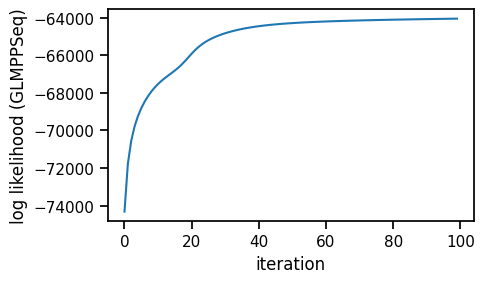

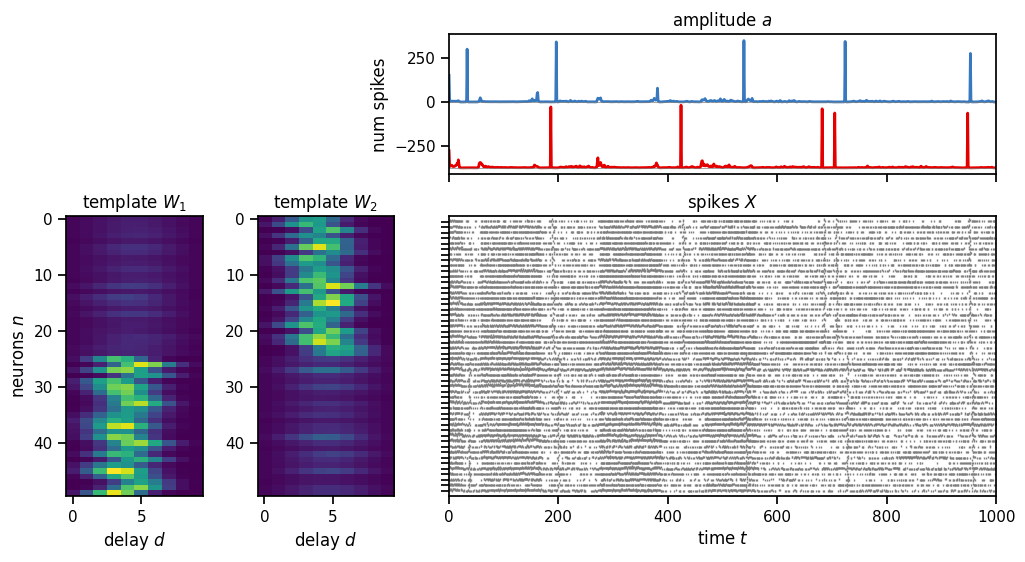

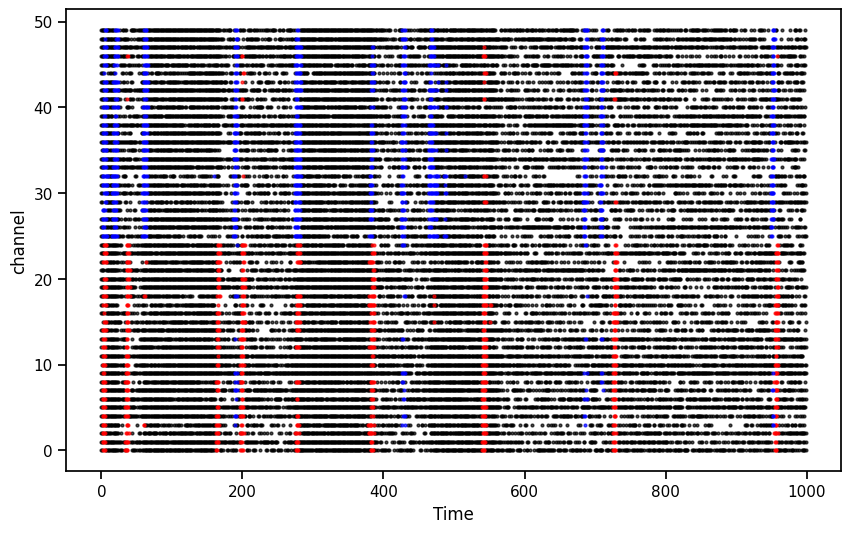

In [23]:
# Apply GLMPPSeq model to the multi-session data
torch.manual_seed(0)
model_glmppseq = GLMPPSeq(num_templates=K,
                          num_neurons=num_neurons,
                          template_duration=D,
                          alpha_a0=1.5,
                          beta_a0=0.2,
                          alpha_b0=1,
                          beta_b0=0.1,
                          alpha_t0=1.2,
                          beta_t0=0.1,
                          device=device,
                          use_bias=True,
                          empirical_glm=True,
                          n_covariates=5,
                          )

lps_glm, amplitudes_glm = model_glmppseq.fit(
    X_full.to(device),
    num_iter=100,
    initialization='random',
    fit_templates=True,
    fit_base_rates=True,
)

plt.figure(figsize=(5,3))
plt.plot(lps_glm.detach().cpu())
plt.xlabel('iteration')
plt.ylabel('log likelihood (GLMPPSeq)')
plt.tight_layout()
plt.show()

plot_model(model_glmppseq.templates.detach().cpu(),
           amplitudes_glm.detach().cpu(),
           X_full.cpu(),
           spc=.33)

color_plot(X_full.cpu(), 
           model_glmppseq, 
           amplitudes_glm.detach().cpu())